
 ## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, zscore

In [68]:
# Set consistent style
sns.set(style="whitegrid", rc={"figure.dpi": 120})

PATHS = {
    "ko_abundance": "../data/ko_abundance_contigs_example.tsv",
    "metadata": "../data/abiotic.csv",
    "kegg_modules": "../data/KEGG_module_database.csv",
    "output_dir": "../output",
    "figure_dir": "../figures"
}

# Biome groups for analysis
BIOME_GROUPS = [
    'Surface', 'Platform', 'Shallow Sinkhole', 
    'Deep Sinkhole', 'Acid Lake', 'Mesopelagic']

# Color palette for sample groups
GROUP_COLORS = {
    'Surface': "#009E73",
    'Platform': "#ddcc77",
    'Shallow Sinkhole': '#a2e7f2',
    'Deep Sinkhole': "#0072B2",
    'Acid Lake': "#E69F00",
    'Mesopelagic': "#CC79A7",
}

 ## Load Data

In [ ]:
print("Loading data...")
ko_df = pd.read_csv(PATHS["ko_abundance"], sep="\t", index_col=0)
meta = pd.read_csv(PATHS["metadata"], sep=",", index_col=0)

print(f"Loaded: {ko_df.shape[0]} KOs, {ko_df.shape[1]} samples")
print(f"Metadata columns: {list(meta.columns)}")
print(meta.head())

 ## Map KOs to KEGG Modules

In [70]:
ko_modules = pd.read_csv(
    PATHS["kegg_modules"], 
    sep=",", 
    index_col=0
).dropna(subset=['KO', 'Module'])

# Extract level classifications
ko_modules[['lv1', 'lv2', 'lv3']] = ko_modules['Class'].str.split(';', expand=True)

# Build KO → Module mapping dictionary
ko_to_mod = {}
for module_id, kos_str in zip(
    ko_modules['Module'], 
    ko_modules['KO'].str.split(';')
):
    for ko in kos_str:
        ko_key = f'ko:{ko}'
        ko_to_mod.setdefault(ko_key, set()).add(module_id)

# Create dictionaries for lookup
mod_to_desc_lv1 = ko_modules[ko_modules['lv1'] != 'Signature modules']\
    .set_index('Module')['lv1'].to_dict()
mod_to_desc_lv2 = ko_modules.set_index('Module')['lv2'].to_dict()
mod_to_desc_lv3 = ko_modules.set_index('Module')['lv3'].to_dict()

print(f"Mapped {len(ko_to_mod)} unique KOs to modules")

Mapped 2803 unique KOs to modules


 ## Aggregate KO Abundances by Biome
 Group samples by biome and compute mean abundance
 Assumes meta has 'Sample' and 'Group' columns matching ko_df columns

In [71]:
def aggregate_by_biome(ko_df, metadata, group_col='Group'):
    """Aggregate KO counts by sample groups defined in metadata."""
    # Merge with metadata to get group assignments
    df = ko_df.T.join(metadata[group_col])
    grouped = df.groupby(group_col).mean().T
    return grouped

ko_df_grouped = aggregate_by_biome(ko_df, meta, 'Cluster')
print(f"Aggregated to {ko_df_grouped.shape[0]} KOs × {ko_df_grouped.shape[1]} biomes")

Aggregated to 99 KOs × 6 biomes


 ## Assign Modules to KO Rows
 Add Module sets to KO dataframe

In [72]:
ko_df_grouped['Modules'] = ko_df_grouped.index.map(ko_to_mod)
ko_df_grouped.dropna(subset=['Modules'], inplace=True)

# Explode and sum to get Module-level abundances
mod_df = (
    ko_df_grouped.reset_index()
    .explode('Modules')
    .groupby('Modules')
    .sum(numeric_only=True)
)

print(f"Aggregated to {mod_df.shape[0]} modules")

Aggregated to 59 modules


 ## Normalize and Z-score Transform
 Row-wise normalization (per module across samples)

In [73]:
mod_df_norm = mod_df.div(mod_df.sum(axis=1), axis=0)
# Filter to biome columns only (if extra columns exist)
biome_cols = [c for c in BIOME_GROUPS if c in mod_df_norm.columns]
mod_df_bio = mod_df_norm[biome_cols]

# Z-score transform across samples
mod_zscore = zscore(mod_df_bio, axis=1, nan_policy='omit')
# Convert back to DataFrame (zscore returns numpy array)
mod_zscore = pd.DataFrame(
    mod_zscore, 
    index=mod_df_bio.index, 
    columns=mod_df_bio.columns
)

# Add descriptions
mod_zscore['Description_lv2'] = mod_zscore.index.map(mod_to_desc_lv2)
mod_zscore['Description_lv3'] = mod_zscore.index.map(mod_to_desc_lv3)

print(f"Z-scored {mod_zscore.shape[0]} modules")

Z-scored 59 modules


 ## Overall Heatmap (All Modules)

Saved: module_heatmap_all.svg


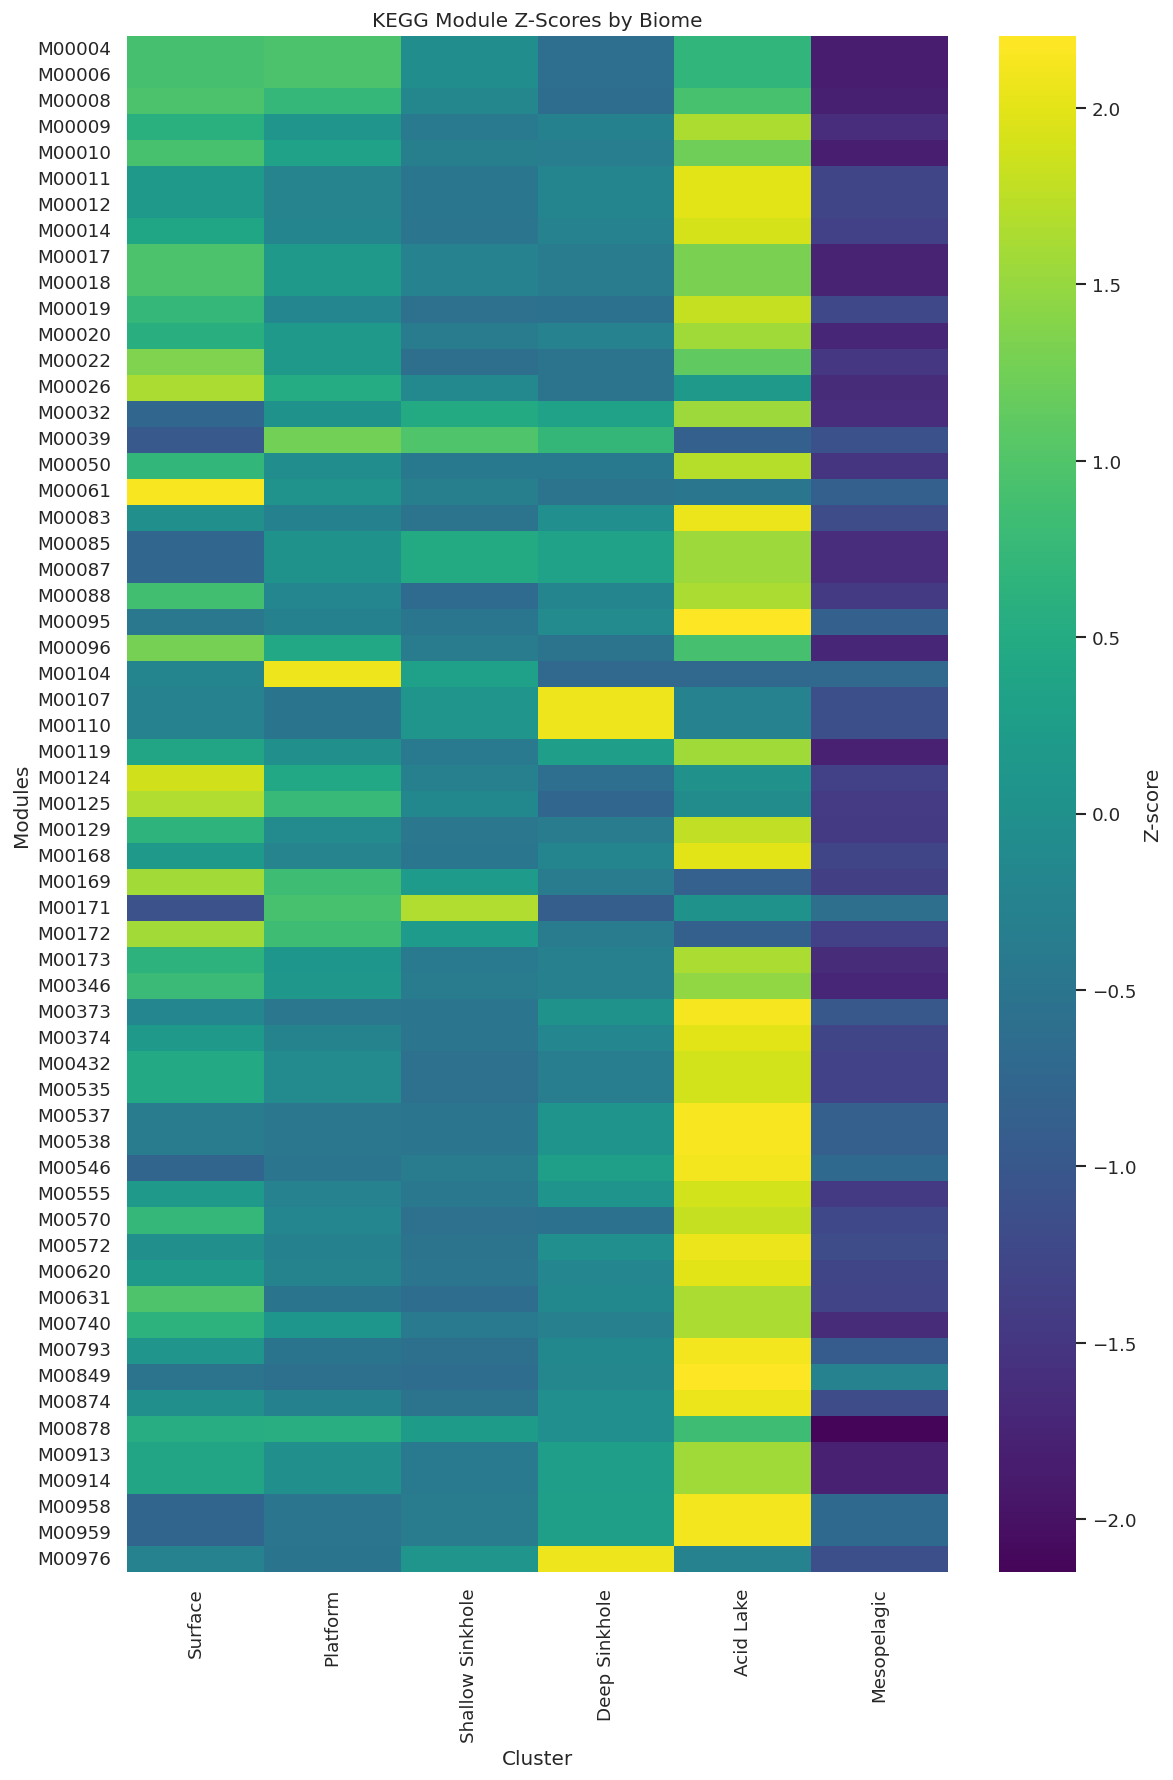

In [74]:
plt.figure(figsize=(10, 15))
ax = sns.heatmap(
    mod_zscore.drop(columns=['Description_lv2', 'Description_lv3']),
    cmap='viridis', 
    center=0, 
    cbar_kws={'label': 'Z-score'}
)
ax.set_title('KEGG Module Z-Scores by Biome')
plt.tight_layout()
plt.savefig(f"{PATHS['figure_dir']}/module_heatmap_all.svg")
print("Saved: module_heatmap_all.svg")
plt.show()

 ## Per-Level-3 Heatmaps

In [ ]:
unique_lv3 = mod_zscore['Description_lv3'].unique()
print(f"Found {len(unique_lv3)} Level 3 categories")

SORT_BY = 'Acid Lake'

for category in unique_lv3:
    # Filter and aggregate by level-3 description
    mask = mod_zscore['Description_lv3'] == category
    if mask.sum() <= 1:
        continue  # Skip single-row categories
    
    mod_cat = mod_zscore[mask].copy()
    # Drop description columns, aggregate remaining
    mod_agg = mod_cat.groupby('Description_lv2')[biome_cols].mean()\
        .fillna(0).sort_values(by=SORT_BY, ascending=False)
    
    if len(mod_agg) < 1:
        continue
    
    # Generate plot
    fig, ax = plt.subplots(figsize=(6, 2 * len(mod_agg)))
    sns.heatmap(
        mod_agg,
        cmap='viridis', 
        center=0, 
        cbar_kws={'label': 'Z-score'},
        annot=False
    )
    ax.set_title(f"{category} ({len(mod_agg)} modules)")
    plt.tight_layout()
    
    # Save
    safe_name = category.replace(' ', '_').replace('/', '_')
    filepath = f"{PATHS['figure_dir']}/module_heatmap_{safe_name}.svg"
    fig.savefig(filepath)
    print(f"  ✓ Saved: {safe_name}.svg")
    plt.close(fig)

print(f"Generated {len(unique_lv3)} category heatmaps")
print(f"All outputs saved to: {PATHS['output_dir']}")